# 14: Learning from search as a separate training stage

[Course home](../README.md) · [Part III chapters](../chapters/README.md#part-iii-inference-time-reasoning-and-planning) · Topics **47–48**

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/notebooks/14_learning_from_search.ipynb)

**Created by Shivam Bharadwaj**

Restart the kernel and run all cells. Defaults run on CPU using generated data and a transparent
categorical arithmetic policy. This is not an LLM benchmark. Colab clones published main when
necessary; local runs need the complete repository and its core requirements.

**Task contract:** left-to-right addition, three proposed intermediate sums, frozen error
probabilities, one unit per proposal, and a declared scorer-query cost. Independent final
evaluation is outside the inference allowance and cannot guide search. Count abstentions as
failures. The code is MIT; educational text and outputs use CC BY 4.0.

In [1]:
from pathlib import Path
import sys
import subprocess

# Local: open from the full checkout. Colab: clone the published course once.
roots = [Path.cwd(), Path.cwd().parent, Path('/content/rl-course')]
root = next((p for p in roots if (p / 'rl_course' / 'inference.py').exists()), None)
if root is None and 'google.colab' in sys.modules:
    root = Path('/content/rl-course')
    if not root.exists():
        subprocess.run(['git', 'clone', '--depth', '1',
                        'https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git', str(root)], check=True)
if root is None or not (root / 'rl_course' / 'inference.py').exists():
    raise RuntimeError('Use the complete updated repository. Colab uses published main; push Part III before opening its badge.')
sys.path.insert(0, str(root))

import math
import random
from statistics import mean
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from rl_course.inference import (Task, Trace, FrozenPolicy, METHODS, infer, evaluate,
                                 process_score, make_tasks, benchmark, distill)

plt.rcParams.update({'figure.figsize': (9, 4), 'figure.facecolor': '#f5f1e8',
                     'axes.facecolor': '#ffffff', 'text.color': '#292332',
                     'axes.labelcolor': '#292332', 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
COLORS = ['#292332', '#af824a', '#768165', '#87708c', '#95654f']
policy = FrozenPolicy()
tasks = make_tasks(100, seed=2026)
seeds = (7, 19, 41)
budgets = (6, 12, 24, 48)

def show_rows(rows):
    lines = ['| Method | Budget | Answer | Process | Oracle candidates | Used units | Completion |',
             '|---|---:|---:|---:|---:|---:|---:|']
    keys = list(dict.fromkeys((r['method'], r['budget']) for r in rows))
    for method, budget in keys:
        group = [r for r in rows if r['method'] == method and r['budget'] == budget]
        avg = lambda key: mean(r[key] for r in group)
        lines.append(f"| {method} | {budget} | {avg('answer_correct'):.1%} | {avg('process_valid'):.1%} | "
                     f"{avg('candidate_oracle_success'):.1%} | {avg('spent'):.1f} | {avg('completed'):.1%} |")
    display(Markdown('\n'.join(lines)))

def plot_rows(rows, metric='answer_correct', xmetric='budget'):
    fig, ax = plt.subplots()
    for color, method in zip(COLORS, dict.fromkeys(r['method'] for r in rows)):
        groups = [[r for r in rows if r['method'] == method and r['budget'] == b]
                  for b in sorted(set(r['budget'] for r in rows))]
        x = [mean(r[xmetric] for r in group) for group in groups]
        y = [mean(r[metric] for r in group) for group in groups]
        ax.plot(x, y, marker='o', label=method, color=color)
        # Show every generation-seed aggregate; these are not training seeds.
        for xx, group in zip(x, groups):
            ax.scatter([xx] * len(group), [r[metric] for r in group], color=color, alpha=.35, s=18)
    ax.set(xlabel='Budget cap' if xmetric == 'budget' else 'Mean work units actually used',
           ylabel=metric.replace('_', ' '), ylim=(-.03, 1.03))
    ax.legend(fontsize=8); fig.tight_layout(); plt.show()

print('Python', sys.version.split()[0], '| NumPy', np.__version__)
print('Frozen offsets (-1, 0, +1):', policy.probabilities)
print('100 unique tasks, 3 generation seeds; no model downloads or parameter updates during inference.')

Python 3.12.4 | NumPy 2.5.3
Frozen offsets (-1, 0, +1): (0.1, 0.4, 0.5)
100 unique tasks, 3 generation seeds; no model downloads or parameter updates during inference.


## 1. Separate teacher generation from student fitting

Search does not mutate the teacher. After collecting accepted traces, a separate
supervised counting update fits a new categorical student. This is filtered imitation,
not PPO, GRPO, or language-model fine-tuning. The simulator already computes local
arithmetic; the student learns only three error probabilities.

In [2]:
train = make_tasks(100, seed=81, low=0, high=10)
test = make_tasks(100, seed=2026, low=10, high=30)
assert set(train).isdisjoint(test)
teacher = FrozenPolicy()
original_probabilities = teacher.probabilities
students = {}
metadata = {}
for acceptance in ('outcome', 'process'):
    students[acceptance], metadata[acceptance] = distill(train, teacher, budget=24, seed=7, acceptance=acceptance)
    print(acceptance, metadata[acceptance])
    print('Student error probabilities:', students[acceptance].probabilities)
assert teacher.probabilities == original_probabilities
print('Teacher unchanged; student objects fitted after search.')

outcome {'tasks': 100, 'accepted': 36, 'teacher_search_units': 2400, 'acceptance': 'outcome', 'counts_with_pseudocounts': [2, 107, 2]}
Student error probabilities: (0.018018018018018018, 0.963963963963964, 0.018018018018018018)
process {'tasks': 100, 'accepted': 35, 'teacher_search_units': 2400, 'acceptance': 'process', 'counts_with_pseudocounts': [1, 106, 1]}
Student error probabilities: (0.009259259259259259, 0.9814814814814815, 0.009259259259259259)
Teacher unchanged; student objects fitted after search.


## 2. Check the maximum-likelihood calculation

Counts come only from accepted teacher traces. Unit pseudocounts preserve positive
support. Outcome-only acceptance can include compensating mistakes; process acceptance
requires each intermediate step to be valid.

In [3]:
for name, student in students.items():
    counts = metadata[name]['counts_with_pseudocounts']
    expected = tuple(c/sum(counts) for c in counts)
    assert student.probabilities == expected
    print(name, 'accepted:', metadata[name]['accepted'], 'of', len(train))
print('Example final-correct but invalid trace:', evaluate(Task((1,1,5)), Trace((3,7))))

outcome accepted: 36 of 100
process accepted: 35 of 100
Example final-correct but invalid trace: {'completed': True, 'answer_correct': True, 'process_valid': False}


## 3. Frozen held-out evaluation

Compare single-sample behavior of teacher and students, then include teacher best-of-N
at a larger allowance as a separate system. The probability fit is frozen before this
test. Three seeds vary generation, not training initialization. Held-out operand ranges
do not establish learned arithmetic generalization because the simulator supplies it.

| Method | Budget | Answer | Process | Oracle candidates | Used units | Completion |
|---|---:|---:|---:|---:|---:|---:|
| teacher | 3 | 22.7% | 8.3% | 22.7% | 3.0 | 100.0% |
| outcome_student | 3 | 91.0% | 90.7% | 91.0% | 3.0 | 100.0% |
| process_student | 3 | 94.3% | 94.0% | 94.3% | 3.0 | 100.0% |
| teacher_with_search | 24 | 34.7% | 31.7% | 71.7% | 24.0 | 100.0% |

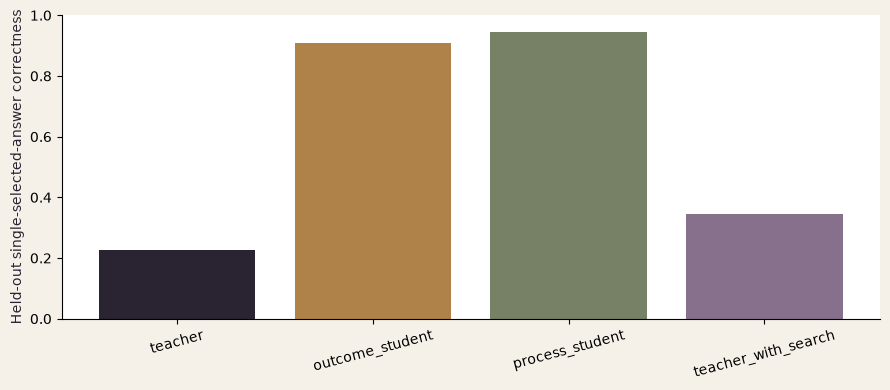

In [4]:
policies = {'teacher': teacher, 'outcome_student': students['outcome'], 'process_student': students['process']}
evaluation_rows = []
for name, candidate in policies.items():
    candidate_rows = benchmark(test, methods=('single',), budgets=(3,), seeds=seeds, policy=candidate)
    evaluation_rows.extend([{**row, 'method': name} for row in candidate_rows])
teacher_search = benchmark(test, methods=('best_of_n',), budgets=(24,), seeds=seeds, policy=teacher)
evaluation_rows.extend([{**row, 'method': 'teacher_with_search'} for row in teacher_search])
show_rows(evaluation_rows)
fig, ax = plt.subplots()
names = list(dict.fromkeys(r['method'] for r in evaluation_rows))
values = [mean(r['answer_correct'] for r in evaluation_rows if r['method']==name) for name in names]
ax.bar(names, values, color=COLORS[:4]); ax.set(ylabel='Held-out single-selected-answer correctness', ylim=(0,1))
ax.tick_params(axis='x', rotation=15); fig.tight_layout(); plt.show()

## 4. Include the cost of producing the student

Teacher search units are reported below. The count fit is computationally trivial here
and is not charged as model training FLOPs. For a real model, training, verification,
and serving must be measured in compatible resource units before claiming savings.

In [5]:
for name, meta in metadata.items():
    teacher_units = meta['teacher_search_units']
    print(name, 'teacher data-generation units:', teacher_units)
    print('Illustrative search-only break-even tasks:', math.ceil(teacher_units/(24-3)))
print('Break-even is meaningful only if the student meets the required quality.')

outcome teacher data-generation units: 2400
Illustrative search-only break-even tasks: 115
process teacher data-generation units: 2400
Illustrative search-only break-even tasks: 115
Break-even is meaningful only if the student meets the required quality.


## 5. Exercises

1. Repeat with teacher budgets 4, 12, and 48. Report accepted trajectories per unit spent.
2. Use the misleading scorer for teacher selection, retaining independent acceptance checks.
3. Separate training and validation task ranges before choosing the teacher budget; reserve another range for final evaluation.
4. Explain what would be required to replace the categorical student with a real language model.

<details><summary>Answers and investigation guidance</summary>

1. A larger search budget can improve acceptance per task while reducing accepted traces per work unit.
   Measure both; neither trend is guaranteed for arbitrary scorers.
2. Check acceptance counts before interpreting the student. No accepted traces yields the smoothed prior,
   not a successfully trained solution policy.
3. Make all budget/selector decisions on validation data. Keep the final task set untouched until the policy is fixed.
4. Tokenize prompt/completion pairs, mask response likelihoods correctly, choose and record a checkpoint,
   train on accepted traces, and evaluate generated outputs on meaningful held-out tasks with measured compute.

</details>

Read [STaR](https://arxiv.org/abs/2203.14465),
[Chapter 47](../chapters/47-learning-from-search/README.md), and the
[small-model SFT/DPO lab](09_small_model_sft_dpo.ipynb) for related masking and checkpoint practice.